# CELL-FM — Condensate Titration

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BoHuangLab/CELL-FM/blob/master/notebooks/condensate_titration.ipynb)

**CELL-FM** is a virtual microscopy model that bridges microscopy images and protein
sequences. This notebook runs one of its applications end to end: predicting how an
**intrinsically disordered peptide (IDP)** behaves as its concentration rises.

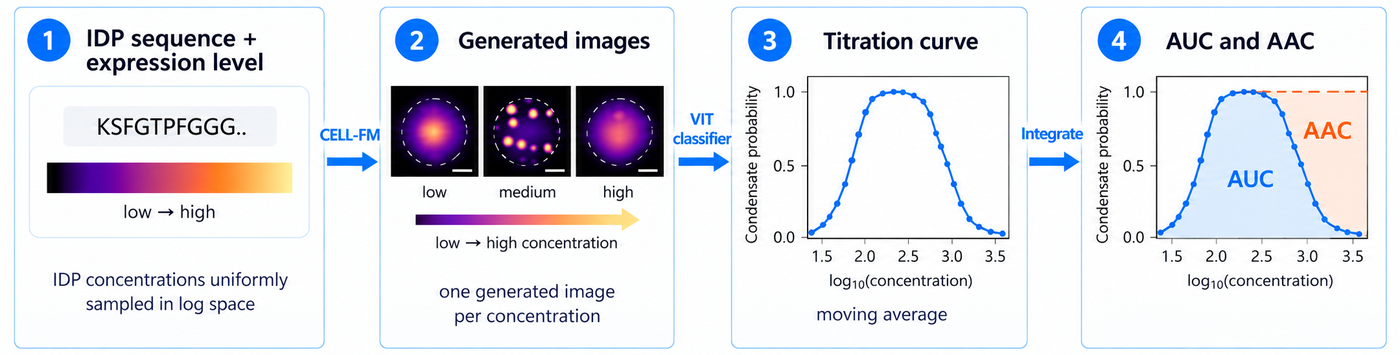

*The four stages, end to end. How many concentrations the ladder holds is set by the
preset in section 3.*

Give it a 66-residue sequence and three stages turn it into a number:

| Stage | What runs | Output |
| --- | --- | --- |
| **1 · Generate** | CELL-FM samples one microscopy image per protein-intensity level, along a log-spaced concentration ladder from 20 to 2048 a.u. | a stack of 2-channel 160×160 images |
| **2 · Classify** | a ViT calls each image **condensed** or **diffuse** | one binary call per image |
| **3 · Summarise** | a centred moving average over those calls is the **titration curve**; integrating it against log-intensity gives AUC and AAC | two numbers in [0, 1] |

**AUC** — the area *under* the titration curve: how much of the scanned concentration
range the sequence spends in the condensed state. Higher means it condenses more
readily, over a wider range of concentrations.

**AAC** — the area *above* it: condensation lost to **reentrant dissolution**. The curve
is compared against the one it would have followed had it never come back down
(everything past the maximum held flat), and AAC is the gap between the two. It is zero
when a sequence condenses and stays condensed, and grows the more it re-dissolves at
high concentration.

Both are normalised by the width of the log-intensity range, so both lie in [0, 1] and
are directly comparable between sequences.

---

**You need a GPU runtime.** *Runtime → Change runtime type → T4 GPU*; the free tier is
enough. Setup downloads about 4.4 GB of weights once, then each sequence takes a couple
of minutes at the default preset. On CPU everything still runs, but a single sequence
would take hours.

| | |
| --- | --- |
| Weights | [huggingface.co/BoHuangLab/CELL-FM](https://huggingface.co/BoHuangLab/CELL-FM) |
| Code | [github.com/BoHuangLab/CELL-FM](https://github.com/BoHuangLab/CELL-FM) |
| Hosted app | [huggingface.co/spaces/BoHuangLab/CELL-FM](https://huggingface.co/spaces/BoHuangLab/CELL-FM) |


## 1 · Setup

Four cells: check the runtime, install what Colab does not already ship, fetch the demo
code and weights, and build the models. Run them once, in order.


In [ ]:
import subprocess
import sys

print("python  ", sys.version.split()[0])
try:
    gpu = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
        capture_output=True, text=True,
    ).stdout.strip()
except FileNotFoundError:
    gpu = ""
print("gpu     ", gpu if gpu else
      "NONE — Runtime > Change runtime type > T4 GPU, then rerun this cell")


In [ ]:
# Colab already ships torch, pandas and matplotlib; this adds the rest of the stack.
# Three choices below look odd and are deliberate:
#
#   --no-deps on esm   its metadata requires torchtext, which has no wheel past Python
#                      3.11 and would drag torch backwards. Nothing on the ESM-C code
#                      path imports it — the second line is what the import closure
#                      actually needs, esm's other bounds included.
#   "transformers<4.47"  esm's own bound, and it is behavioural rather than cosmetic.
#                      4.47 replaced the special-token properties on PreTrainedTokenizer
#                      with a _special_tokens_map served through __getattr__. esm 3.1.4's
#                      EsmSequenceTokenizer still expects the property, so on anything
#                      newer tokenizer.mask_token is None and generation dies inside
#                      esm/utils/encoding.py with "replace() argument 2 must be str, not
#                      None". 4.46.3 is the last release with the property, and it pulls
#                      tokenizers 0.20 and huggingface_hub 0.36, both of which have
#                      wheels for this Python.
#   "numpy<2"          esm 3.1.4 pins biotite==0.41.2, which needs NumPy 1.x and sits on
#                      the ESM-C import path: esm.utils.structure.protein_chain imports
#                      biotite.structure.io.npz, a module biotite deleted in 1.0. So the
#                      pin cannot be escaped by taking a newer biotite, and NumPy has to
#                      come down.
#   "pandas<3"         which drags this one with it. Most wheels built against NumPy 2
#                      still run under 1.x, but pandas 3 calls np.dtypes.StringDType, a
#                      NumPy 2 API that simply is not there in 1.x, so importing Colab's
#                      pandas under the pin dies with
#                      "module 'numpy.dtypes' has no attribute 'StringDType'".
#                      pandas 2.2.3 is the last release that works here, and it ships a
#                      wheel for this Python, so the pin costs nothing.
#   no flash-attn      without it ESM-C falls back to a pure-torch rotary embedding,
#                      verified to give identical results, and skips a CUDA build.
import sys

if sys.version_info >= (3, 13):
    print(f"Python {sys.version_info.major}.{sys.version_info.minor}: NumPy 1.x and "
          "biotite 0.41.2 have no wheels this new, so pip builds both from source.\n"
          "That works — it just makes this cell take a few minutes.\n")

%pip install -q --no-deps "esm==3.1.4"
%pip install -q "numpy<2" "pandas<3" "transformers<4.47" "diffusers==0.31.0" torchdiffeq loguru accelerate "biotite==0.41.2" biopython msgpack-numpy cloudpathlib tenacity brotli zstd attrs einops

import importlib.metadata as md

# pip prints two kinds of complaint above and neither is a failure:
#
#   "esm 3.1.4 requires torchtext"                       left unenforced on purpose:
#       nothing on the ESM-C code path imports it, and it has no wheel for this Python.
#       esm's transformers bound, by contrast, IS enforced above — it is real.
#   "<package> requires numpy>=2"                        Colab preinstalls opencv, jax,
#       shap and friends and none of them are imported here. A wheel compiled against
#       NumPy 2 still runs under 1.x, so most of those keep working anyway; what does
#       not survive is a package calling a NumPy 2 *Python* API, which is why pandas is
#       pinned above. If some other import ever dies on a missing numpy attribute, that
#       is the same problem and the same fix.
#
# What actually has to be true is checked below.
print("\nversions")
for pkg in ("torch", "numpy", "pandas", "transformers", "diffusers", "esm", "biotite"):
    try:
        print(f"  {pkg:14s} {md.version(pkg)}")
    except md.PackageNotFoundError:
        print(f"  {pkg:14s} MISSING")

def _below(pkg, major, minor):
    got = tuple(int(x) for x in md.version(pkg).split(".")[:2])
    return got < (major, minor)


ready = (md.version("numpy").startswith("1.")
         and md.version("pandas").startswith("2.")
         and md.version("biotite") == "0.41.2"
         and _below("transformers", 4, 47))
print("\nNumPy 1.x, pandas 2.x, biotite 0.41.2, transformers < 4.47:",
      "yes — the imports below will work" if ready else
      "NO — the next cell will fail; rerun this one")

# A pin landing on disk is not the same as this kernel using it. Colab imports NumPy at
# startup, and if an earlier attempt got as far as the next cell then transformers is
# imported too — pip then downgrades it underneath a kernel that goes on holding the old
# module in memory. So compare what is imported against what is installed, for everything
# pinned, and restart if any of them disagree. Expected, not a crash: Colab reconnects on
# its own and you carry on from the next cell, without rerunning this one.
stale = []
for pkg in ("numpy", "pandas", "transformers", "tokenizers", "huggingface_hub", "biotite"):
    loaded = getattr(sys.modules.get(pkg), "__version__", None)
    try:
        installed = md.version(pkg)
    except md.PackageNotFoundError:
        continue
    if loaded is not None and loaded != installed:
        stale.append(f"{pkg} {loaded} -> {installed}")

if stale:
    import os, time
    print("\nRestarting the kernel so these take effect — expected, not a crash:")
    for line in stale:
        print("   ", line)
    print("Colab reconnects by itself; continue from the next cell.")
    time.sleep(1)
    os.kill(os.getpid(), 9)


In [ ]:
import os
import sys
import time

# transformers decides at import time whether a TensorFlow backend is available, and
# image_transforms.py then acts on it with `if is_tf_available(): import tensorflow`.
# Colab has TensorFlow; its tflite utils import jax; jax/_src/dtypes.py calls
# np.dtypes.StringDType() at module level — a NumPy 2 API that does not exist under the
# numpy<2 pin this stack requires. Nothing here uses either backend, so switch both off
# before transformers is first imported. The JAX one is spelled USE_FLAX in the
# environment even though the code calls it USE_JAX.
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import transformers
from huggingface_hub import snapshot_download

# Two things about transformers have to hold, and neither is visible from the version on
# disk — both are properties of what this kernel is holding in memory.
#
# esm 3.1.4 needs < 4.47: 4.47 dropped the tokenizer's mask_token property, and without it
# generation dies six frames inside esm on "replace() argument 2 must be str, not None".
if tuple(int(x) for x in transformers.__version__.split(".")[:2]) >= (4, 47):
    raise RuntimeError(
        f"This kernel has transformers {transformers.__version__} loaded; esm 3.1.4 "
        "needs < 4.47. If the install cell above already pins it, the kernel is holding "
        "the old module: Runtime > Restart session, then run the cells again from the top."
    )

# And the TensorFlow backend has to be off. It will not be if transformers was already
# imported earlier in this session, before the environment variables above were set.
if transformers.utils.is_tf_available():
    raise RuntimeError(
        "transformers has its TensorFlow backend enabled, which pulls in jax and fails "
        "under NumPy 1.x. That means it was imported before this cell set USE_TF: "
        "Runtime > Restart session, then run the cells again from the top."
    )

# The demo code lives in the public Space, so this notebook runs exactly what the hosted
# app runs: same model configs, same reference nucleus, same metrics. ~400 kB.
CODE = snapshot_download(repo_id="BoHuangLab/CELL-FM", repo_type="space")
sys.path.insert(0, CODE)

# NumPy 2 renamed trapz to trapezoid. metrics.py is written against NumPy 1, which the
# cell above installs; the alias only matters if that ever stops being true.
if not hasattr(np, "trapz"):
    np.trapz = np.trapezoid

import metrics
import pipeline

print("code    ", CODE)
print("weights ", pipeline.MODEL_REPO)
print("device  ", pipeline.get_device())

# One palette for every figure below: blue is the titration curve and the area under it,
# orange the area above it, aqua a sequence that passed validation in section 2.
CURVE, GAP, OTHER = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "font.size": 9,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
})


In [ ]:
# 2.1 GB of CELL-FM checkpoints, plus 2.3 GB for the ESM-C 600M protein encoder the
# generator is built around (fetched by the esm package the first time the model is
# constructed). Both are cached, so rerunning this cell is instant.
t0 = time.time()
pipeline.load_models()                                      # built on CPU, then moved
generator, classifier, tokenizer = pipeline.models_on(pipeline.get_device())

params = lambda m: sum(p.numel() for p in m.parameters()) / 1e6
print(f"generator   {params(generator):6.0f}M params   flow matching, ESM-C 600M encoder + image VAE")
print(f"classifier  {params(classifier):6.0f}M params   ViT, 2-channel 160x160 input")
print(f"\nready on {pipeline.get_device()} in {time.time() - t0:.0f}s")


## 2 · Choose a sequence

The input should be **66 amino acids**. That is not a convenience limit: all sequences in 
the CondenSeq library CELL-FM was trained on are 66-mers, so any other length is off-distribution.

The box below opens on the **NUP98 IDP**. Type or paste your own 66-mer over it: it
validates as you type, and whatever is valid in the box is what every cell below runs.


In [ ]:
SEQUENCE = "KSFGTPFGGGTGGFGTTSTFGQNTGFGTTSGGAFGTSAFGSSNNTGGLFGNSQTKPGGLFGTSSFS"  # NUP98 IDP

sequence = pipeline.clean_sequence(SEQUENCE)


def _commit(_=None):
    """Validate what is in the box and hand it to the rest of the notebook.

    pipeline.clean_sequence is the check the model itself applies, so the box refuses
    exactly what the model would refuse, and says so before anything is generated. An
    invalid edit leaves the last good sequence in place rather than half-applying.
    """
    global sequence
    try:
        candidate = pipeline.clean_sequence(box.value)
    except ValueError as exc:
        status.value = (
            f"<span style='color:{GAP}'>&#10007; {exc}</span><br>"
            f"<span style='color:{MUTED}'>Still using the last valid sequence, "
            f"{len(sequence)} aa — that is what the cells below will run.</span>")
        return
    sequence = candidate
    status.value = (
        f"<span style='color:{OTHER}'>&#10003;</span> {len(sequence)} aa &middot; "
        f"{sequence.count('F')} phenylalanine stickers")


try:
    import ipywidgets as widgets
    from IPython.display import display

    box = widgets.Textarea(value=SEQUENCE, continuous_update=True,
                           layout=widgets.Layout(width="99%", height="66px"))
    status = widgets.HTML()
    box.observe(_commit, names="value")

    display(widgets.VBox([
        widgets.HTML("<b>Sequence</b> &mdash; 66 amino acids, single-letter. "
                     "FASTA headers are stripped."),
        box, status,
    ]))
    _commit()
except ImportError:
    print("ipywidgets unavailable — edit SEQUENCE above and rerun this cell.\n")

print(sequence)
print(f"{len(sequence)} aa, {sequence.count('F')} phenylalanine stickers")


## 3 · Stage 1 — generate the concentration ladder

CELL-FM generates one image per protein-intensity level, over `NUM_IMAGES` log-spaced
levels from 20 to 2048 a.u. Every image is conditioned on **the same fixed reference
nucleus**, so that between two runs the only things that differ are the sequence and 
the concentration — which is what makes curves comparable across sequences.

Sampling is seeded, so a rerun reproduces a run exactly. Generation is the expensive
stage: the protein encoder runs once per ODE step, so ladder length × step count sets
the runtime.

| Preset | Ladder | ODE steps |
| --- | --- | --- |
| `quick` | 256 | 100 |
| `standard` | 512 | 100 |



In [ ]:
PRESET = "quick"  # @param ["quick", "standard"]
SEED = 6  # @param {type:"integer"}
BATCH_SIZE = 64  # @param {type:"integer"}

LADDER = {"quick": (256, 100), "standard": (512, 100)}
NUM_IMAGES, NUM_STEPS = LADDER[PRESET]

from tqdm.auto import tqdm


def generate(seq):
    """Stage 1 for one sequence, with pipeline's fractional progress fed to tqdm."""
    bar = tqdm(total=NUM_IMAGES, desc="generating", unit="img")
    try:
        return pipeline.generate_images(
            seq, NUM_IMAGES, NUM_STEPS, BATCH_SIZE, seed=SEED,
            progress=lambda fraction, desc=None: (
                setattr(bar, "n", int(fraction * NUM_IMAGES)), bar.refresh()),
        )
    finally:
        bar.n = NUM_IMAGES
        bar.refresh()
        bar.close()


if str(pipeline.get_device()) == "cpu":
    print("No GPU — this will take hours. Switch the runtime to a GPU, or set "
          "NUM_IMAGES to ~16 below just to watch it work.\n")

t0 = time.time()
images = generate(sequence)
gen_seconds = time.time() - t0

intensities = pipeline.intensity_ladder(NUM_IMAGES).numpy()
print(f"{images.shape[0]} images, {images.shape[2]}x{images.shape[3]}, "
      f"2 channels (nucleus, protein), {images.dtype}")
print(f"{gen_seconds:.0f}s total — {gen_seconds / NUM_IMAGES:.2f}s per image")
print(f"ladder: {intensities[0]:.0f} to {intensities[-1]:.0f} a.u., log-spaced over "
      f"{NUM_IMAGES} levels")


In [ ]:
# 64 images spread evenly along the ladder, and the nucleus every one of them was
# conditioned on. Condensation shows up as bright puncta against the diffuse pool.
#
# Each panel is min-max normalised on its own, so the faintest images are legible instead
# of sitting near black. That is a display choice with a cost: it throws away the
# brightness difference between panels, which is the very thing the ladder varies. Read
# shape here — whether the protein is dispersed or in puncta — not intensity. The
# classifier in the next stage sees the raw uint16, not this.
COLUMNS = 8
panel_count = min(64, NUM_IMAGES)
protein, levels = pipeline.sample_panel(images, intensities, k=panel_count)
nucleus = (pipeline.reference_nucleus()[0, 0].numpy() + 1) / 2


def minmax(img):
    """Stretch one image to [0, 1]. A flat image stays flat rather than dividing by zero."""
    lo, hi = float(img.min()), float(img.max())
    return (img - lo) / (hi - lo) if hi > lo else np.zeros_like(img)


fig, ax = plt.subplots(figsize=(1.6, 1.8))
ax.imshow(minmax(nucleus), cmap="gray")
ax.set_title("reference nucleus\nfixed conditioning", fontsize=8, color=MUTED)
ax.set_axis_off()
plt.show()

rows = -(-panel_count // COLUMNS)
fig, axes = plt.subplots(rows, COLUMNS, figsize=(11.5, 1.55 * rows))
for i, ax in enumerate(np.atleast_1d(axes).flat):
    if i < panel_count:
        ax.imshow(minmax(protein[i]), cmap="magma")
        ax.set_title(f"{levels[i]:.0f}", fontsize=6, color=MUTED, pad=2)
    ax.set_axis_off()
fig.suptitle(f"generated protein channel at {panel_count} points along the concentration "
             "ladder (a.u.), each panel min-max normalised", fontsize=10, y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


## 4 · Stage 2 — classify each image

A ViT trained on real CondenSeq microscopy calls each generated image **condensed** or
**diffuse**, seeing both channels.

The images are handed over as `uint16`, which is deliberate: the offline pipeline wrote a
TIFF between generation and classification, so the classifier saw quantised pixels.
Keeping that round-trip here keeps these numbers comparable to the published ones.


In [ ]:
import textwrap

predictions = pipeline.classify_images(images, BATCH_SIZE)
condensed = int(predictions.sum())

print(f"{condensed} / {len(predictions)} images called condensed "
      f"({condensed / len(predictions):.0%} of the ladder)")
print("\nper-image calls, low to high concentration  (# condensed, . diffuse):\n")
print(textwrap.fill("".join("#" if p else "." for p in predictions), 96))


## 5 · Stage 3 — the titration curve

The per-image calls are binary and noisy. The curve is their **centred moving average**. 
The window is fixed at 1/8 of the ladder, so smoothing is comparable across presets.

The scatter behind the curve is the raw calls, kept visible so the curve is always
readable as a summary of something.

In [ ]:
from dataclasses import dataclass


def moving_average(y, window: int):
    """Centred rolling mean, shrinking the window at the edges rather than padding.

    Spelled out rather than imported because it is the whole of stage 3's smoothing and
    everything downstream is an integral of its output. The body is the same as
    metrics.moving_average, which the AUC and AAC below call internally -- the assert
    below holds the two to that.
    """
    y = np.asarray(y, dtype=float)
    window = int(max(1, min(window, len(y))))
    return (
        pd.Series(y)
        .rolling(window=window, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )


assert np.array_equal(moving_average(predictions, 8),
                      metrics.moving_average(predictions, 8))


@dataclass
class Titration:
    sequence: str
    intensities: np.ndarray
    predictions: np.ndarray
    curve: np.ndarray
    window: int
    auc: float
    aac: float


def summarise(sequence, intensities, predictions):
    """Stage 3: smooth the binary calls, then integrate the curve."""
    df = pd.DataFrame({"protein_intensity_level": intensities,
                       "predicted_class": predictions})
    window = max(1, len(predictions) // pipeline.WINDOW_DIVISOR)
    kw = dict(window_size=window, use_log_scale=True)
    return Titration(
        sequence=sequence, intensities=intensities, predictions=predictions,
        curve=moving_average(predictions, window), window=window,
        auc=metrics.compute_area_under_curve(df, **kw),
        aac=metrics.compute_area_above_curve(df, **kw),
    )


def plot_titration(t, ax=None):
    """The curve, with the two integrated areas drawn as the areas they are."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7.2, 3.8))
    flat = metrics.no_reentrant_curve(t.curve)

    ax.scatter(t.intensities, t.predictions, s=6, alpha=0.16, color=MUTED,
               linewidths=0, zorder=1)
    ax.fill_between(t.intensities, 0, t.curve, color=CURVE, alpha=0.18, linewidth=0,
                    zorder=2, label=f"AUC {t.auc:.3f}   condensed")
    if t.aac > 1e-9:
        ax.fill_between(t.intensities, t.curve, flat, where=flat > t.curve, color=GAP,
                        alpha=0.30, linewidth=0, zorder=3,
                        label=f"AAC {t.aac:.3f}   lost to reentrance")
        ax.plot(t.intensities, flat, color=GAP, linewidth=1.2, linestyle="--",
                alpha=0.8, zorder=4)
    ax.plot(t.intensities, t.curve, color=CURVE, linewidth=2.0, zorder=5)

    ax.set_xscale("log")
    ax.set_xlim(t.intensities.min(), t.intensities.max())
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("protein intensity level (a.u., log scale)")
    ax.set_ylabel("condensate probability")
    ax.grid(True, alpha=0.18, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(loc="upper left", frameon=False, fontsize=9)
    ax.set_title("condensate titration curve", fontsize=10, loc="left")
    return ax


base = summarise(sequence, intensities, predictions)

plot_titration(base)
plt.show()

print(f"AUC     {base.auc:.4f}    area under the curve — condensation propensity")
print(f"AAC     {base.aac:.4f}    area above the curve — reentrant dissolution")
